In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("youtube_videos.csv")

df.head()

,link,title,description,category
0,JLZlCZ0,Ep 1| Travelling through North East India | Of...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nT...,travel
1,i9E_Blai8vk,Welcome to Bali | Travel Vlog | Priscilla Lee,Priscilla Lee\n45.6K subscribers\nSUBSCRIBE\n*...,travel
2,r284c-q8oY,My Solo Trip to ALASKA | Cruising From Vancouv...,Allison Anderson\n588K subscribers\nSUBSCRIBE\...,travel
3,Qmi-Xwq-ME,Traveling to the Happiest Country in the World!!,Yes Theory\n6.65M subscribers\nSUBSCRIBE\n*BLA...,travel
4,_lcOX55Ef70,Solo in Paro Bhutan | Tiger's Nest visit | Bhu...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nH...,travel


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3599 entries, 0 to 3598
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   link         3599 non-null   object
 1   title        3599 non-null   object
 2   description  3599 non-null   object
 3   category     3599 non-null   object
dtypes: object(4)
memory usage: 112.6+ KB


In [3]:
df.isnull().sum()

link           0
title          0
description    0
category       0
dtype: int64

In [4]:
df['category'].value_counts()

category
travel       1156
art_music     947
food          903
history       593
Name: count, dtype: int64

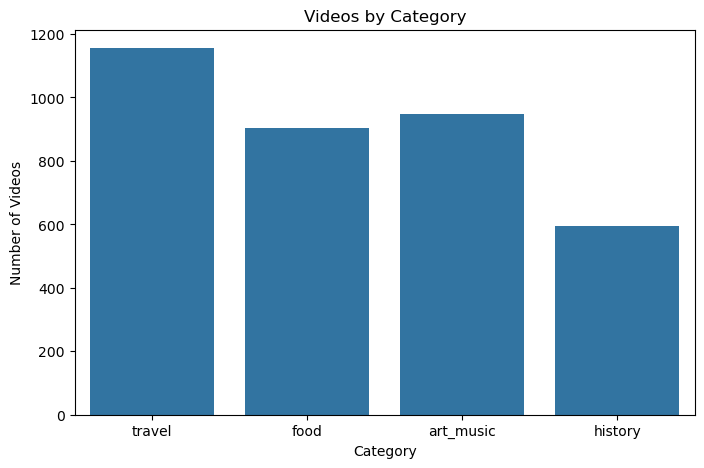

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x='category', data=df)

plt.title("Videos by Category")
plt.xlabel("Category")
plt.ylabel("Number of Videos")

plt.show()

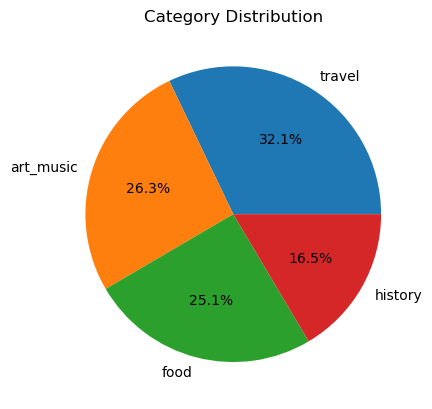

In [6]:
df['category'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Category Distribution")
plt.ylabel("")

plt.show()

In [7]:
df['title'].head(10)

0    Ep 1| Travelling through North East India | Of...
1        Welcome to Bali | Travel Vlog | Priscilla Lee
2    My Solo Trip to ALASKA | Cruising From Vancouv...
3     Traveling to the Happiest Country in the World!!
4    Solo in Paro Bhutan | Tiger's Nest visit | Bhu...
5    Koh Phangan: 'New Thailand' for Indian Family ...
6    Amazing Kerala story | Why I went Rainforest A...
7    EP 14 Meghalaya Tour complete Travel Guide | N...
8    Summer Vacation in Ladakh | 6 Day Itinerary | ...
9    Kerala's best beaches in Varkala! Cliff cafes,...
Name: title, dtype: object

In [8]:
df.sample(10)

,link,title,description,category
149,WSF9FZAcbak,#writeforus #WriteforUsTravel | Write for us T...,Tarni Infotech\n28 subscribers\nSUBSCRIBE\nWri...,travel
1028,5frBArKZxpE,Homeless In America | अमेरिका के भिखारी / बेघर...,Rohan Virdi\n380K subscribers\nSUBSCRIBE\nHome...,travel
2090,5IwXZKpzBHE,Flowers Coloring Pages Salt Painting for Kids ...,Jay Lee Painting\n2.43M subscribers\nSUBSCRIBE...,art_music
2332,WfLNyR_Csx0,HATA_RE_TO_HATA_DE 🤗♥️ || BIKI POP &PUJA || PO...,POP MUSIC\n37.9K subscribers\nJOIN\nSUBSCRIBE\...,art_music
2958,EfAaHYBlh0,New Punjabi Songs 2020 - 2021 Lamborghini Offi...,Single Track Studio\n9.2M subscribers\nSUBSCRI...,art_music
1292,PjJVpsd00Pg,Indian Street Food | Famous Papdi Chaat Of Ind...,Indian Food Explorer\n47.1K subscribers\nSUBSC...,food
2785,Y7DiV8RPw8,Best Workout Songs | Best Motivational Song | ...,Mitwaa Love\n65.7K subscribers\nSUBSCRIBE\nThi...,art_music
322,fSror3ztYj4,Travel,Travel blog\nSUBSCRIBE\nHere you can find me: ...,travel
2398,W7OJ9nxl6,BUTTER With ZERO BUDGET! BTS Butter K-POP MUSI...,The KJAR Crew\n302K subscribers\nSUBSCRIBE\nWh...,art_music
750,WHRLwjCB9hM,Why did we not make this before ? 😲 | Indian V...,NaanAndLuchi Travels\nSUBSCRIBE\nWhen we decid...,travel


In [9]:
df['title_length'] = df['title'].apply(len)

df[['title','title_length']].head()

,title,title_length
0,Ep 1| Travelling through North East India | Of...,92
1,Welcome to Bali | Travel Vlog | Priscilla Lee,45
2,My Solo Trip to ALASKA | Cruising From Vancouv...,61
3,Traveling to the Happiest Country in the World!!,48
4,Solo in Paro Bhutan | Tiger's Nest visit | Bhu...,100


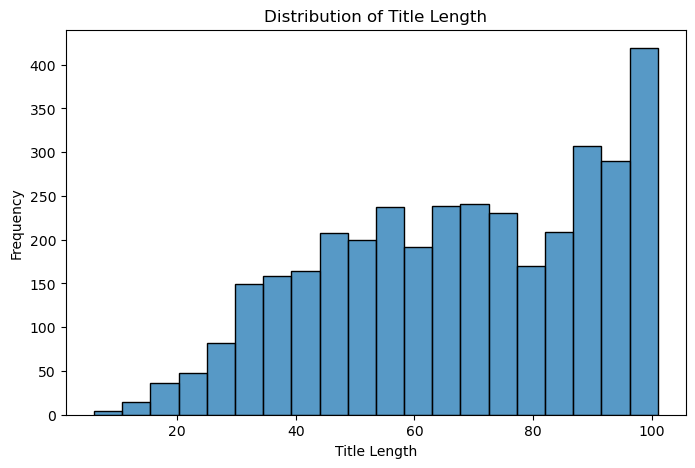

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['title_length'], bins=20)

plt.title("Distribution of Title Length")
plt.xlabel("Title Length")
plt.ylabel("Frequency")

plt.show()

In [12]:
from collections import Counter

words = " ".join(df['title']).split()

Counter(words).most_common(10)

[('|', 2560),
 ('-', 901),
 ('Songs', 792),
 ('in', 758),
 ('2021', 736),
 ('Food', 610),
 ('Indian', 548),
 ('History', 415),
 ('of', 409),
 ('New', 352)]

In [13]:
!pip install wordcloud

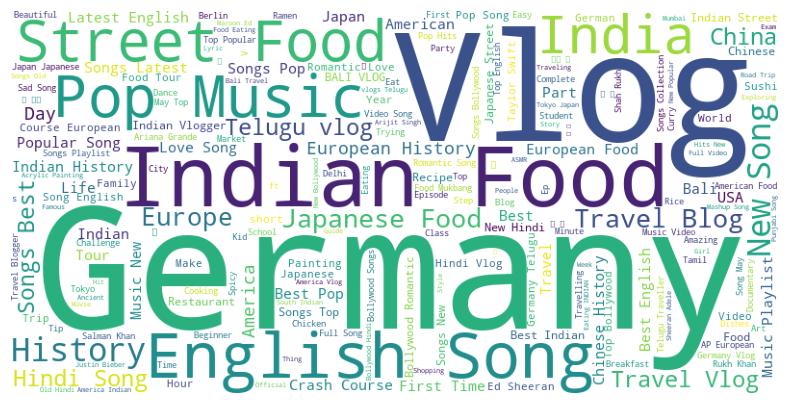

In [14]:
from wordcloud import WordCloud

text = " ".join(df['title'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")

plt.show()

In [15]:
df.groupby('category')['title_length'].mean()

category
art_music    78.980993
food         62.826135
history      64.197302
travel       63.616782
Name: title_length, dtype: float64

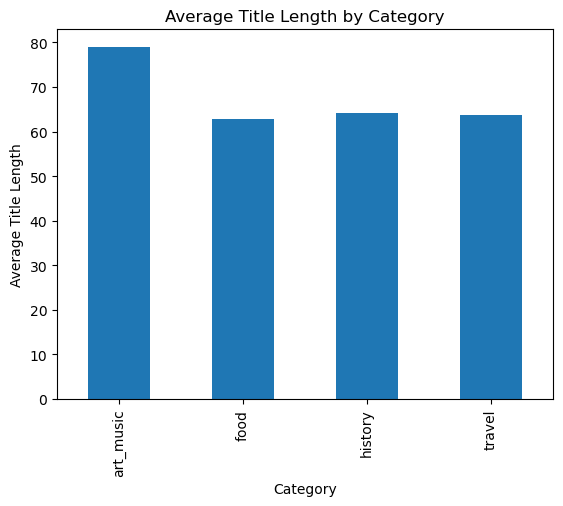

In [16]:
df.groupby('category')['title_length'].mean().plot(kind='bar')

plt.title("Average Title Length by Category")
plt.xlabel("Category")
plt.ylabel("Average Title Length")

plt.show()

In [17]:
print("Total Videos:", len(df))
print("Categories:", df['category'].unique())
print("Most Common Category:", df['category'].value_counts().idxmax())

Total Videos: 3599
Categories: ['travel' 'food' 'art_music' 'history']
Most Common Category: travel


In [18]:
!pip install streamlit